<a href="https://colab.research.google.com/github/cris54654/practica_regresion_lineal_co2/blob/main/Practica_guiada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practica Guiada: Regresion Lineal Simple

**Nombre:** CrisTofer Reyes  
**Curso:** Inteligencia Artificial
**Tema:** Regresion Lineal Simple  
**Herramienta:** Google Colab  
**Dataset:** FuelConsumptionCo2  

## Introduccion

En esta practica se implementa un modelo de regresion lineal simple utilizando Python y la libreria Scikit-learn. El objetivo es analizar un dataset de consumo de combustible y emisiones de CO2 para entrenar un modelo capaz de predecir las emisiones de CO2 de los vehiculos.

Tambien se aplicara validacion cruzada K-Fold y regresion multiple para comparar la precision de diferentes modelos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import linear_model
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Carga del dataset

En esta seccion se carga el archivo CSV que contiene informacion sobre vehiculos, consumo de combustible y emisiones de CO2.

In [6]:
df = pd.read_csv("FuelConsumptionCo2 (1).csv")

df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## Exploracion de datos

Se realiza una exploracion inicial del dataset para conocer sus columnas, cantidad de registros y estadisticas generales.

In [13]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [15]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


## Seleccion de variables

Se seleccionan las variables numericas principales que seran utilizadas para analizar la relacion con las emisiones de CO2.

In [16]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]

cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


## Visualizacion de datos

Se grafican histogramas para observar la distribucion de las variables seleccionadas.

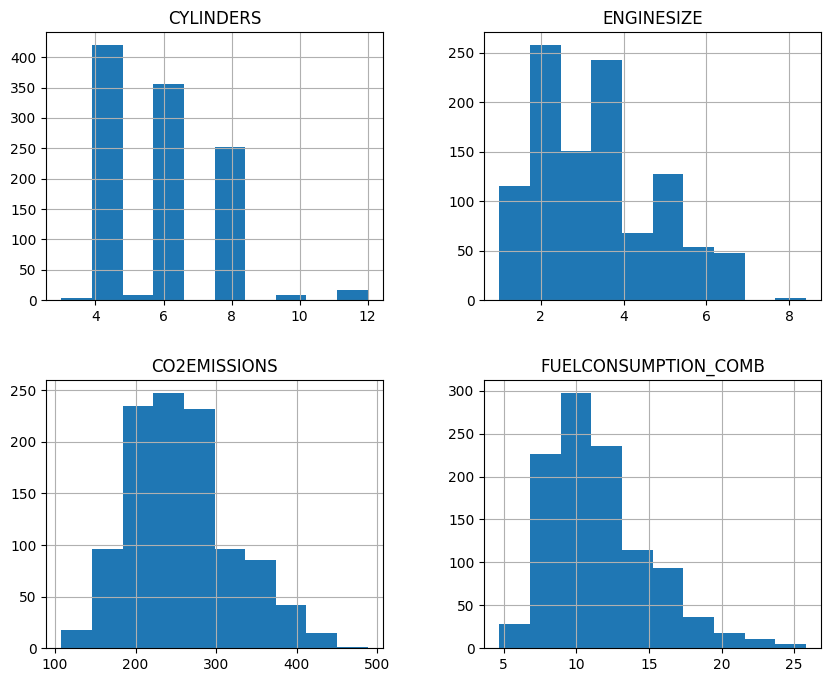

In [17]:
viz = cdf[['CYLINDERS', 'ENGINESIZE', 'CO2EMISSIONS', 'FUELCONSUMPTION_COMB']]

viz.hist(figsize=(10, 8))
plt.show()

## Relacion entre variables y emisiones de CO2

Se realizan graficas de dispersion para observar que tan lineal es la relacion entre las variables independientes y las emisiones de CO2.

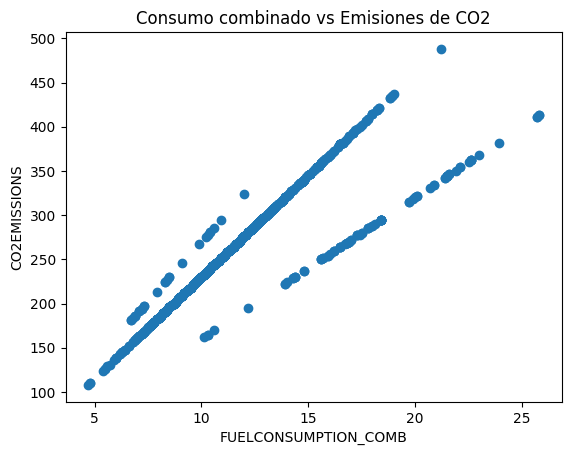

In [18]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS)
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.title("Consumo combinado vs Emisiones de CO2")
plt.show()

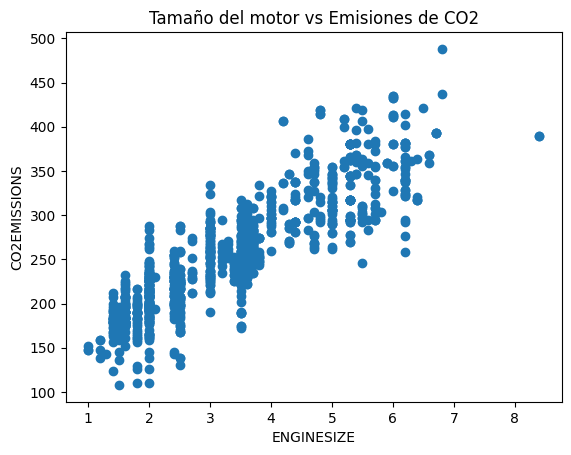

In [20]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS)
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.title("Tamaño del motor vs Emisiones de CO2")
plt.show()

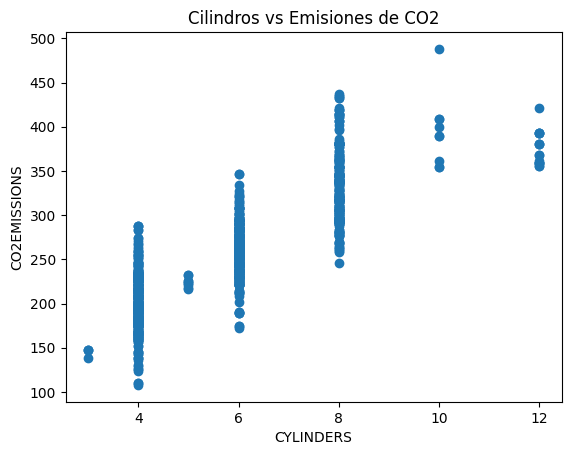

In [21]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS)
plt.xlabel("CYLINDERS")
plt.ylabel("CO2EMISSIONS")
plt.title("Cilindros vs Emisiones de CO2")
plt.show()

### Analisis de las graficas

Las graficas muestran que existe una relacion positiva entre el tamano del motor, el consumo de combustible y las emisiones de CO2. Esto significa que, en general, mientras mayor es el motor o mayor es el consumo de combustible, mayores son las emisiones de CO2.

La variable CYLINDERS tambien tiene relacion con las emisiones, aunque la distribucion se observa mas agrupada porque los cilindros suelen tomar valores discretos como 4, 6 u 8.

## Separacion del dataset

El dataset se divide en dos partes: un conjunto de entrenamiento y un conjunto de prueba. El 80% de los datos se usa para entrenar el modelo y el 20% para evaluarlo.

In [22]:
train, test = train_test_split(cdf, test_size=0.2, random_state=42)

print("Datos de entrenamiento:", train.shape)
print("Datos de prueba:", test.shape)

Datos de entrenamiento: (853, 4)
Datos de prueba: (214, 4)


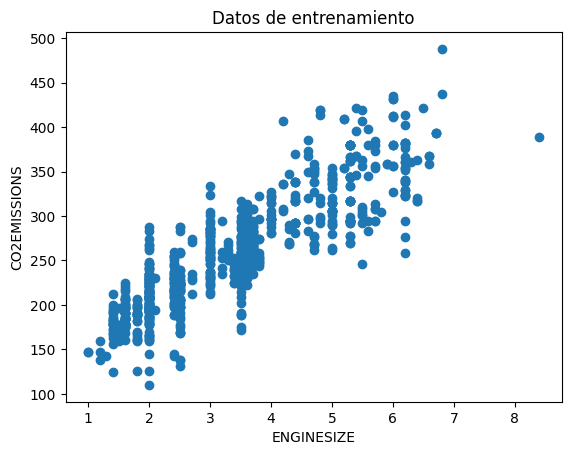

In [23]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS)
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.title("Datos de entrenamiento")
plt.show()

## Modelo de regresion lineal simple

Se crea un modelo de regresion lineal simple utilizando la variable ENGINESIZE para predecir CO2EMISSIONS.

In [24]:
regr = linear_model.LinearRegression()

train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

regr.fit(train_x, train_y)

print("Coeficiente:", regr.coef_)
print("Intercepto:", regr.intercept_)

Coeficiente: [[38.99297872]]
Intercepto: [126.28970217]


In [25]:
coeficiente = regr.coef_[0][0]
intercepto = regr.intercept_[0]

print("Polinomio generado por el modelo:")
print(f"CO2EMISSIONS = {coeficiente:.2f} * ENGINESIZE + {intercepto:.2f}")

Polinomio generado por el modelo:
CO2EMISSIONS = 38.99 * ENGINESIZE + 126.29


## Polinomio generado

La ecuacion de regresion lineal tiene la forma:

CO2EMISSIONS = m * ENGINESIZE + b

Donde:
- m representa el coeficiente o pendiente.
- b representa el intercepto.
- ENGINESIZE es la variable independiente.
- CO2EMISSIONS es la variable dependiente.

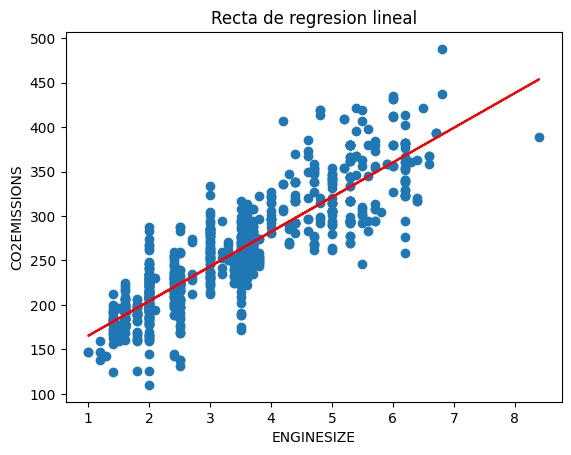

In [26]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS)

plt.plot(
    train_x,
    coeficiente * train_x + intercepto,
    '-r'
)

plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.title("Recta de regresion lineal")
plt.show()

## Evaluacion del modelo

Se evalua el modelo utilizando el conjunto de prueba. Para medir la precision se utilizan las metricas MAE, MSE y R2-score.

In [27]:
test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])

test_y_pred = regr.predict(test_x)

mae = mean_absolute_error(test_y, test_y_pred)
mse = mean_squared_error(test_y, test_y_pred)
r2 = r2_score(test_y, test_y_pred)

print("Error medio absoluto MAE:", round(mae, 2))
print("Error cuadratico medio MSE:", round(mse, 2))
print("R2-score:", round(r2, 2))

Error medio absoluto MAE: 24.1
Error cuadratico medio MSE: 985.94
R2-score: 0.76


# Reto: K-Fold Cross Validation

Se utiliza K-Fold Cross Validation para comparar diferentes variables y determinar cual genera un mejor modelo de regresion lineal simple.

In [28]:
variables = [
    'ENGINESIZE',
    'CYLINDERS',
    'FUELCONSUMPTION_COMB'
]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for variable in variables:
    X = df[[variable]]
    y = df['CO2EMISSIONS']

    modelo = linear_model.LinearRegression()
    scores = cross_val_score(modelo, X, y, cv=kf, scoring='r2')

    modelo.fit(X, y)

    print("Variable:", variable)
    print("R2 promedio:", round(scores.mean(), 4))
    print("Coeficiente:", round(modelo.coef_[0], 4))
    print("Intercepto:", round(modelo.intercept_, 4))
    print(f"Polinomio: CO2EMISSIONS = {modelo.coef_[0]:.2f} * {variable} + {modelo.intercept_:.2f}")
    print("--------------------------------")

Variable: ENGINESIZE
R2 promedio: 0.7618
Coeficiente: 39.1252
Intercepto: 125.3041
Polinomio: CO2EMISSIONS = 39.13 * ENGINESIZE + 125.30
--------------------------------
Variable: CYLINDERS
R2 promedio: 0.7186
Coeficiente: 29.9572
Intercepto: 82.6342
Polinomio: CO2EMISSIONS = 29.96 * CYLINDERS + 82.63
--------------------------------
Variable: FUELCONSUMPTION_COMB
R2 promedio: 0.7934
Coeficiente: 16.22
Intercepto: 68.3871
Polinomio: CO2EMISSIONS = 16.22 * FUELCONSUMPTION_COMB + 68.39
--------------------------------


# Modelo de regresion multiple

En esta seccion se implementa un modelo de regresion multiple utilizando varias variables independientes para mejorar la prediccion de CO2EMISSIONS.

In [29]:
X = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = df['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_multiple = linear_model.LinearRegression()
modelo_multiple.fit(X_train, y_train)

predicciones = modelo_multiple.predict(X_test)

print("Coeficientes:", modelo_multiple.coef_)
print("Intercepto:", modelo_multiple.intercept_)

print("MAE:", round(mean_absolute_error(y_test, predicciones), 2))
print("MSE:", round(mean_squared_error(y_test, predicciones), 2))
print("R2:", round(r2_score(y_test, predicciones), 2))

Coeficientes: [11.2094395   7.15561381  9.5208118 ]
Intercepto: 67.3483851836209
MAE: 16.72
MSE: 512.86
R2: 0.88


In [30]:
X = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y = df['CO2EMISSIONS']

modelo_multiple = linear_model.LinearRegression()

scores_multiple = cross_val_score(modelo_multiple, X, y, cv=kf, scoring='r2')

print("R2 promedio con K-Fold en regresion multiple:", round(scores_multiple.mean(), 4))
print("Desviacion estandar:", round(scores_multiple.std(), 4))

R2 promedio con K-Fold en regresion multiple: 0.8618
Desviacion estandar: 0.0128


## Variables poco significativas

Al comparar los resultados de K-Fold, las variables con menor R2 promedio pueden considerarse menos significativas individualmente.

En este caso, CYLINDERS puede ser menos significativa que otras variables como ENGINESIZE o FUELCONSUMPTION_COMB, ya que por si sola puede explicar menos variacion de las emisiones.

Sin embargo, una variable poco significativa de forma individual no siempre debe eliminarse automaticamente, porque dentro de un modelo multiple puede aportar informacion complementaria.

# Conclusion

En esta practica se implemento un modelo de regresion lineal simple para predecir las emisiones de CO2 utilizando el tamano del motor como variable principal.

Los resultados muestran que existe una relacion positiva entre ENGINESIZE y CO2EMISSIONS, ya que los vehiculos con motores mas grandes tienden a generar mayores emisiones.

Tambien se aplico K-Fold Cross Validation para comparar diferentes variables y se implemento un modelo de regresion multiple. El modelo multiple puede mejorar la precision porque utiliza mas informacion del dataset.

En conclusion, la regresion lineal permite analizar y predecir emisiones de CO2, pero el modelo mejora cuando se consideran varias variables relacionadas con el consumo de combustible y las caracteristicas del vehiculo.